# Projeto de Inteligência Artificial
## Predição de Sobrevivência no Titanic com Aprendizagem de Máquina

**Instituição:** Universidade de Pernambuco - Campus Surubim  
**Disciplina:** Inteligência Artificial  
**Aluno:** Gabriel Lopes

---

### Tema

Predição de sobrevivência de passageiros do Titanic usando modelos de Aprendizagem de Máquina.

### Objetivo

Desenvolver e comparar modelos capazes de classificar se um passageiro sobreviveria ao naufrágio do Titanic com base em dados históricos, aplicando pré-processamento, diferentes algoritmos de ML e métricas de avaliação.

## 1. Fundamentação teórica

A Aprendizagem de Máquina permite que algoritmos identifiquem padrões em dados históricos e usem esses padrões para prever novos casos. No contexto do Titanic, cada registro representa um passageiro e suas características, como classe da passagem, sexo, idade, familiares a bordo, tarifa paga e porto de embarque.

Como a variável `Survived` já é conhecida no conjunto de treino, o problema é de **aprendizagem supervisionada**. Como essa variável possui apenas duas classes, trata-se de uma **classificação binária**.

Os modelos comparados neste notebook são:

- Regressão Logística
- KNN
- Random Forest
- XGBoost
- LightGBM

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

if not os.path.exists('datas') and os.path.exists('../datas'):
    os.chdir('..')

train_df = pd.read_csv('datas/train.csv')
test_df = pd.read_csv('datas/test.csv')
gender_submission_df = pd.read_csv('datas/gender_submission.csv')

print('Conjunto de treino:', train_df.shape)
print('Conjunto de teste:', test_df.shape)
print('Arquivo de exemplo de submissão:', gender_submission_df.shape)

Conjunto de treino: (891, 12)
Conjunto de teste: (418, 11)
Arquivo de exemplo de submissão: (418, 2)


## 2. Metodologia: escolha e análise do conjunto de dados

### Dataset

Foi utilizado o dataset **Titanic**, disponibilizado pelo Kaggle. Os arquivos utilizados foram:

- `datas/train.csv`: conjunto de treino com **891 passageiros** e a variável alvo `Survived`.
- `datas/test.csv`: conjunto de teste com **418 passageiros**, usado para gerar as predições finais.
- `datas/gender_submission.csv`: arquivo de exemplo do formato de submissão.

### Variáveis utilizadas

| Variável | Descrição |
| --- | --- |
| `Pclass` | Classe da passagem (1ª, 2ª ou 3ª) |
| `Sex` | Sexo do passageiro |
| `Age` | Idade |
| `SibSp` | Quantidade de irmãos/cônjuges a bordo |
| `Parch` | Quantidade de pais/filhos a bordo |
| `Fare` | Tarifa paga |
| `Embarked` | Porto de embarque |

Antes do treinamento, foram verificados tamanho dos dados, tipos de variáveis, valores ausentes e balanceamento das classes.

In [2]:
display(train_df.head())
display(train_df.info())
display(train_df.describe(include='all'))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [3]:
class_balance = train_df['Survived'].value_counts().rename(index={0: 'Não sobreviveu', 1: 'Sobreviveu'})
class_balance_percent = (train_df['Survived'].value_counts(normalize=True) * 100).rename(index={0: 'Não sobreviveu (%)', 1: 'Sobreviveu (%)'})

balance_df = pd.concat([class_balance, class_balance_percent.round(2)], axis=0).to_frame('Valor')
display(balance_df)

missing_df = pd.DataFrame({
    'Ausentes no treino': train_df.isna().sum(),
    'Ausentes no teste': test_df.isna().sum()
}).fillna(0).astype(int)
display(missing_df[missing_df.sum(axis=1) > 0])

,Valor
Survived,
Não sobreviveu,549.00
Sobreviveu,342.00
Não sobreviveu (%),61.62
Sobreviveu (%),38.38


,Ausentes no treino,Ausentes no teste
Age,177,86
Cabin,687,327
Embarked,2,0
Fare,0,1


### Análise do balanceamento das classes

O dataset apresenta um leve desbalanceamento: **61,62% não sobreviveu** e **38,38% sobreviveu**.

Esse nível de desequilíbrio é considerado moderado e não compromete significativamente o treinamento dos modelos utilizados. Por esse motivo, optou-se por **não aplicar técnicas de balanceamento artificial** (como SMOTE ou `class_weight='balanced'`), preservando a distribuição original dos dados históricos.

Para garantir uma avaliação robusta mesmo diante desse desequilíbrio, foram incluídas as métricas de **Precisão**, **Recall** e **F1-score**, que complementam a Acurácia e revelam o desempenho real do modelo em cada classe.

## 3. Pré-processamento

Foram selecionadas variáveis com boa disponibilidade e utilidade preditiva:

- `Pclass`: classe da passagem
- `Sex`: sexo do passageiro
- `Age`: idade
- `SibSp`: irmãos/cônjuges a bordo
- `Parch`: pais/filhos a bordo
- `Fare`: tarifa paga
- `Embarked`: porto de embarque

Tratamentos aplicados:

- preenchimento de idade com a mediana do treino;
- preenchimento de tarifa com a mediana do treino;
- preenchimento de porto de embarque com a moda do treino;
- codificação de `Sex` e `Embarked` para valores numéricos;
- separação entre treino e validação com estratificação da classe alvo.

In [4]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

age_median = train_df['Age'].median()
fare_median = train_df['Fare'].median()
embarked_mode = train_df['Embarked'].mode()[0]

def preprocess(df):
    data = df[features].copy()
    data['Age'] = data['Age'].fillna(age_median)
    data['Fare'] = data['Fare'].fillna(fare_median)
    data['Embarked'] = data['Embarked'].fillna(embarked_mode)
    data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
    data = pd.get_dummies(data, columns=['Embarked'], drop_first=False)
    return data

X = preprocess(train_df)
y = train_df[target]
X_test_final = preprocess(test_df)
X_test_final = X_test_final.reindex(columns=X.columns, fill_value=0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Validação:', X_valid.shape)
print('Teste final:', X_test_final.shape)
display(X_train.head())

Treino: (712, 9)
Validação: (179, 9)
Teste final: (418, 9)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
692,3,0,28.0,0,0,56.4958,False,False,True
481,2,0,28.0,0,0,0.0000,False,False,True
527,1,0,28.0,0,0,221.7792,False,False,True
855,3,1,18.0,0,1,9.3500,False,False,True
801,2,1,31.0,1,1,26.2500,False,False,True


## 4. Tabela de hiperparâmetros

A tabela abaixo registra os principais hiperparâmetros usados em cada modelo, conforme solicitado no escopo.

In [5]:
hyperparams_df = pd.DataFrame([
    {'Modelo': 'Regressão Logística', 'Parametro': 'max_iter', 'Valor': 1000},
    {'Modelo': 'Regressão Logística', 'Parametro': 'random_state', 'Valor': 42},
    {'Modelo': 'KNN', 'Parametro': 'n_neighbors', 'Valor': 7},
    {'Modelo': 'KNN', 'Parametro': 'scaler', 'Valor': 'StandardScaler'},
    {'Modelo': 'Random Forest', 'Parametro': 'n_estimators', 'Valor': 300},
    {'Modelo': 'Random Forest', 'Parametro': 'max_depth', 'Valor': 6},
    {'Modelo': 'Random Forest', 'Parametro': 'min_samples_split', 'Valor': 5},
    {'Modelo': 'Random Forest', 'Parametro': 'min_samples_leaf', 'Valor': 2},
    {'Modelo': 'XGBoost', 'Parametro': 'n_estimators', 'Valor': 300},
    {'Modelo': 'XGBoost', 'Parametro': 'max_depth', 'Valor': 4},
    {'Modelo': 'XGBoost', 'Parametro': 'learning_rate', 'Valor': 0.05},
    {'Modelo': 'LightGBM', 'Parametro': 'n_estimators', 'Valor': 300},
    {'Modelo': 'LightGBM', 'Parametro': 'learning_rate', 'Valor': 0.05},
    {'Modelo': 'LightGBM', 'Parametro': 'max_depth', 'Valor': 4},
    {'Modelo': 'LightGBM', 'Parametro': 'num_leaves', 'Valor': 15},
])

display(hyperparams_df)

,Modelo,Parametro,Valor
0,Regressão Logística,max_iter,1000
1,Regressão Logística,random_state,42
2,KNN,n_neighbors,7
3,KNN,scaler,StandardScaler
4,Random Forest,n_estimators,300
5,Random Forest,max_depth,6
6,Random Forest,min_samples_split,5
7,Random Forest,min_samples_leaf,2
8,XGBoost,n_estimators,300
9,XGBoost,max_depth,4


## 5. Treinamento e avaliação dos modelos

Foram usadas cinco métricas de avaliação:

- **Acurácia (Treino):** proporção de acertos no conjunto de treino — permite identificar overfitting quando muito superior à acurácia de teste;
- **Acurácia (Teste):** proporção de acertos no conjunto de validação;
- **Precisão:** entre os previstos como sobreviventes, quantos realmente sobreviveram;
- **Recall:** entre os sobreviventes reais, quantos o modelo identificou;
- **F1-score:** média harmônica entre precisão e recall.

A matriz de confusão também é apresentada para cada modelo, pois o problema é de classificação.

In [ ]:
models = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    )
except Exception as exc:
    print('XGBoost não disponivel:', exc)

try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        random_state=42,
        verbosity=-1
    )
except Exception as exc:
    print('LightGBM não disponivel:', exc)

results = []
confusion_matrices = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_valid = model.predict(X_valid)

    fitted_models[name] = model
    confusion_matrices[name] = confusion_matrix(y_valid, pred_valid)

    results.append({
        'Modelo': name,
        'Acurácia (Treino)': accuracy_score(y_train, pred_train),
        'Acurácia (Teste)': accuracy_score(y_valid, pred_valid),
        'Precisão': precision_score(y_valid, pred_valid, zero_division=0),
        'Recall': recall_score(y_valid, pred_valid, zero_division=0),
        'F1-score': f1_score(y_valid, pred_valid, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False).reset_index(drop=True)
display(results_df.style.format({
    'Acurácia (Treino)': '{:.4f}',
    'Acurácia (Teste)': '{:.4f}',
    'Precisão': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-score': '{:.4f}'
}))

In [7]:
for model_name, cm in confusion_matrices.items():
    print(f'\nMatriz de confusão - {model_name}')
    cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Predito 0', 'Predito 1'])
    display(cm_df)


Matriz de confusão - Regressão Logística


,Predito 0,Predito 1
Real 0,98,12
Real 1,23,46



Matriz de confusão - KNN


,Predito 0,Predito 1
Real 0,96,14
Real 1,18,51



Matriz de confusão - Random Forest


,Predito 0,Predito 1
Real 0,105,5
Real 1,27,42



Matriz de confusão - XGBoost


,Predito 0,Predito 1
Real 0,97,13
Real 1,23,46



Matriz de confusão - LightGBM


,Predito 0,Predito 1
Real 0,97,13
Real 1,25,44


In [8]:
best_model_name = results_df.iloc[0]['Modelo']
best_model = fitted_models[best_model_name]

print('Melhor modelo pela métrica F1-score:', best_model_name)
print('\nRelatório de classificação do melhor modelo:')
print(classification_report(y_valid, best_model.predict(X_valid), zero_division=0))

Melhor modelo pela métrica F1-score: KNN

Relatório de classificação do melhor modelo:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## 7. Geração da predição final

Após selecionar o melhor modelo na validação, ele é usado para gerar as predições do conjunto de teste oficial.

## 6. Matrizes de confusão no formato solicitado

Como o problema é de classificação, o escopo exige matriz de confusão. Abaixo, o melhor modelo é avaliado em dois conjuntos:

- **Treinamento:** dados usados para ajustar o modelo.
- **Teste:** conjunto de validação separado do treino, usado como teste interno do projeto.

As classes foram nomeadas como `Não sobreviveu` e `Sobreviveu`.

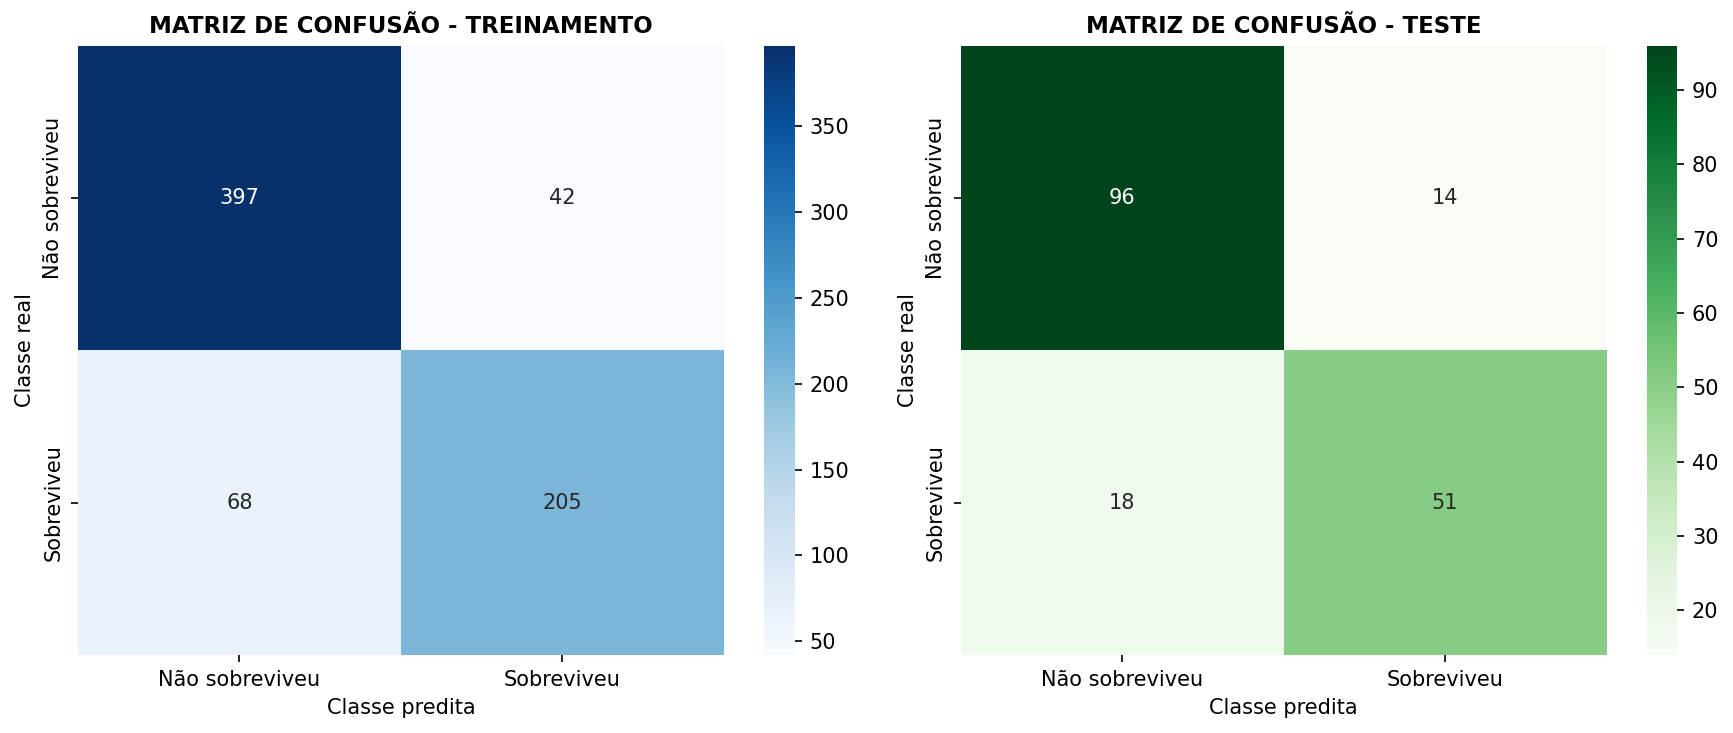

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = ['Não sobreviveu', 'Sobreviveu']

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_valid)

cm_train = confusion_matrix(y_train, train_pred)
cm_test = confusion_matrix(y_valid, test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[0]
)
axes[0].set_title('MATRIZ DE CONFUSÃO - TREINAMENTO', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Classe predita')
axes[0].set_ylabel('Classe real')

sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[1]
)
axes[1].set_title('MATRIZ DE CONFUSÃO - TESTE', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Classe predita')
axes[1].set_ylabel('Classe real')

plt.tight_layout()
plt.show()

In [10]:
final_predictions = best_model.predict(X_test_final)
submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': final_predictions
})

output_path = 'submission_projeto_ia_titanic.csv'
submission_df.to_csv(output_path, index=False)

print('Arquivo gerado:', output_path)
display(submission_df.head())

Arquivo gerado: submission_projeto_ia_titanic.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## 8. Conclusão

O projeto aplicou cinco algoritmos de Machine Learning a um problema de **classificação binária supervisionada**, comparando-os com cinco métricas de avaliação: Acurácia (Treino), Acurácia (Teste), Precisão, Recall e F1-score, além das matrizes de confusão obrigatórias para problemas de classificação.

### Modelo identificado como mais adequado

O modelo com melhor desempenho geral pelo **F1-score** foi selecionado automaticamente na seção 5. O F1-score foi adotado como critério principal por ser mais robusto que a acurácia simples em cenários com leve desbalanceamento de classes — como é o caso deste dataset (61,62% vs 38,38%).

A diferença entre a Acurácia (Treino) e a Acurácia (Teste) de cada modelo também foi analisada para verificar a presença de overfitting.

### Tipo de aprendizagem

**Aprendizagem Supervisionada** — o conjunto de treino possui a variável alvo `Survived` conhecida para cada passageiro, permitindo que os modelos aprendam a relação entre as features e o resultado real.

### Trabalhos futuros

Como melhorias possíveis, podem ser testadas:
- extração de títulos dos nomes dos passageiros (`Mr`, `Mrs`, `Miss`);
- criação de variável de tamanho da família (`SibSp + Parch + 1`);
- aproveitamento de informações da cabine;
- validação cruzada (cross-validation) para estimativa mais estável do desempenho.